In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
import torchvision.transforms.v2 as v2
from copy import deepcopy
import sys
sys.path.append("/n/home11/sambt/phlab-neurips25")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from models.litmodels import SimCLRModel, JetClassSimCLRModel
from models.networks import CustomResNet, MLP
from models.losses import MMDLoss, RBF
from data.datasets import CIFAR10Dataset
from data.cifar import CIFAR5MDataset
import data.data_utils as dutils
from data.jetclass.augmentations import JetCLR_Augmentations
from data.jetclass.augmentations_unbatched import JetCLR_Augmenter

from sklearn.metrics import roc_auc_score, top_k_accuracy_score
from utils.plotting import make_corner, make_corner2
import h5py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from data.datasets import JetClassDataset
dset = JetClassDataset(["qcd","ttbar","wqq","zqq","hbb"],
                       "/n/home11/sambt/phlab-neurips25/configs/jetclass_data_configs/JetClass_full.yaml",
                       limit_test_files=1,
                       batch_size=512,
                       num_workers=1)

In [6]:
m32 = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim32/lightning_logs/l99sp5yj/checkpoints/epoch=13-step=7000.ckpt"
m64 = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim64/lightning_logs/i0y8kn0z/checkpoints/epoch=14-step=1500.ckpt"
m128 = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim128/lightning_logs/2dwdq1ot/checkpoints/epoch=13-step=7000.ckpt"
m256 = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim256/lightning_logs/48pt8mcf/checkpoints/epoch=14-step=7500.ckpt"
m512 = "/n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim512/lightning_logs/pu9vwsnt/checkpoints/epoch=10-step=5500.ckpt"

In [7]:
test_loader = dset.test_dataloader()

In [8]:
for model_path,dim in zip([m32,m64,m128,m256,m512],[32,64,128,256,512]):
    print(f"Evaluating model: {model_path}")
    model = JetClassSimCLRModel.load_from_checkpoint(model_path)
    model = model.to(device)
    model.eval()

    # Get all embeddings and labels for test set
    n_processed = 0
    n_per_class = {}
    all_embeddings = []
    all_labels = []
    all_observers = {}
    for batch in tqdm(test_loader):
        x, labels, observers = batch
        labels = labels['_label_'].numpy()
        for k in x.keys():
            x[k]=x[k].to(device)
        with torch.no_grad():
            embeds = model.encoder(x).cpu().numpy()
        del x
        torch.cuda.empty_cache()
        all_embeddings.append(embeds)
        all_labels.append(labels)
        for k in observers.keys():
            if k not in all_observers.keys():
                all_observers[k] = []
            all_observers[k].append(observers[k].cpu().numpy())
    
    print("Saving embeddings of shape:",np.concatenate(all_embeddings,axis=0).shape)
    with h5py.File(f"outputs/embeddings_withExtras_dim{dim}.h5","w") as fout:
        fout.create_dataset("embeddings",data=np.concatenate(all_embeddings,axis=0))
        fout.create_dataset("labels",data=np.concatenate(all_labels,axis=0))
        for k in all_observers.keys():
            fout.create_dataset(k,data=np.concatenate(all_observers[k],axis=0))

Evaluating model: /n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim32/lightning_logs/l99sp5yj/checkpoints/epoch=13-step=7000.ckpt
cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}


/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'projector' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['projector'])`.


Initialized MLP with input_dim=32, hidden_dims=[32], output_dim=16, dropout=0.0, activation=relu, output_activation=None


0it [00:00, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
977it [05:38,  2.89it/s]


Saving embeddings of shape: (500000, 32)
Evaluating model: /n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim64/lightning_logs/i0y8kn0z/checkpoints/epoch=14-step=1500.ckpt
cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
Initialized MLP with input_dim=64, hidden_dims=[64], output_dim=32, dropout=0.0, activation=relu, output_activation=None


...

Saving embeddings of shape: (500000, 128)
Evaluating model: /n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim256/lightning_logs/48pt8mcf/checkpoints/epoch=14-step=7500.ckpt
cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
Initialized MLP with input_dim=256, hidden_dims=[256], output_dim=128, dropout=0.0, activation=relu, output_activation=None


977it [05:31,  2.94it/s]


Saving embeddings of shape: (500000, 256)
Evaluating model: /n/home11/sambt/phlab-neurips25/runs/jetClass_parT_simCLR_T0.1_noClassifier_dim512/lightning_logs/pu9vwsnt/checkpoints/epoch=10-step=5500.ckpt
cfg_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
cfg_cls_block: {'embed_dim': 128, 'num_heads': 8, 'ffn_ratio': 4, 'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'add_bias_kv': False, 'activation': 'gelu', 'scale_fc': True, 'scale_attn': True, 'scale_heads': True, 'scale_resids': True}
Initialized MLP with input_dim=512, hidden_dims=[512], output_dim=256, dropout=0.0, activation=relu, output_activation=None


977it [05:33,  2.93it/s]


Saving embeddings of shape: (500000, 512)


In [9]:
f1 = h5py.File("/n/holystore01/LABS/iaifi_lab/Lab/sambt/neurips25/jetclass_evals_highDim_forGaia/embeddings_dim32.h5","r")
f2 = h5py.File("/n/holystore01/LABS/iaifi_lab/Lab/sambt/neurips25/jetclass_evals_highDim_forGaia/embeddings_withExtras_dim32.h5","r")

In [13]:
l1 = f1['labels'][()]
l2 = f2['labels'][()]

(0.0, 10000.0)

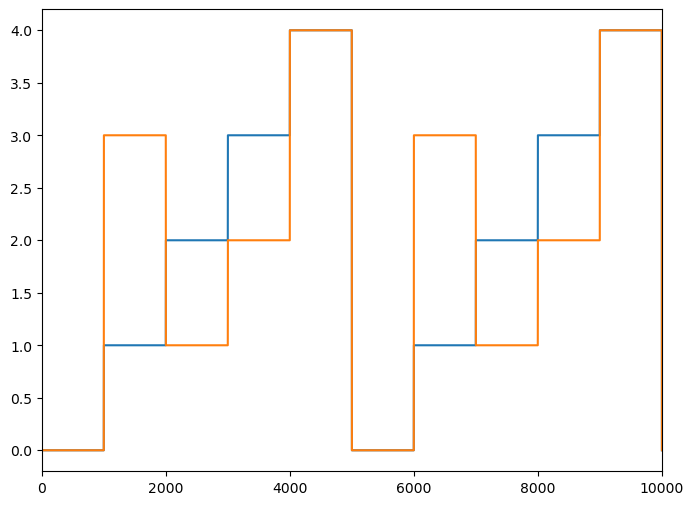

In [22]:
plt.figure(figsize=(8,6))
_=plt.plot(np.arange(len(l1)),l1)
_=plt.plot(np.arange(len(l2)),l2)
plt.xlim([0,10_000])

In [15]:
l1

array([0, 0, 0, ..., 4, 4, 4])